# Sistema de Trading Algorítmico con Backtesting

## Introducción
Este notebook implementa un sistema de trading algorítmico completo basado en el cruce de medias móviles, con backtesting, optimización y análisis detallado del rendimiento.

In [ ]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import warnings

warnings.filterwarnings("ignore")

# Configuración de estilo para gráficos
plt.style.use("seaborn-v0_8-darkgrid")
sns.set_palette("husl")

print("Librerías importadas correctamente")
print(f"Fecha de ejecución: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")

Librerías importadas correctamente
Fecha de ejecución: 2026-05-25 18:33:49


## 1. Definición de Reglas del Sistema de Trading

SISTEMA DE TRADING: CRUCE DE MEDIAS MÓVILES

1. REGLAS DE ENTRADA:
   - Señal de compra: Cuando la Media Móvil Simple (SMA) de corto plazo cruza
     por encima de la SMA de largo plazo
   - Configuración inicial: SMA_10 > SMA_200

2. REGLAS DE SALIDA:
   - Señal de venta: Cuando la SMA de corto plazo cruza por debajo de la SMA
     de largo plazo
   - Configuración inicial: SMA_10 < SMA_200

3. GESTIÓN DEL TAMAÑO DE LA POSICIÓN:
   - 100% del capital disponible en cada operación (all-in)
   - No se permite apalancamiento
   - Solo operaciones largas (no short selling)

4. GESTIÓN DEL RIESGO:
   - Sin stop-loss fijo (la señal de salida actúa como stop)
   - Control de drawdown mediante análisis posterior
   - Monitoreo de volatilidad del sistema

5. PARÁMETROS INICIALES:
   - Media móvil corta: 10 días
   - Media móvil larga: 200 días
   - Capital inicial: $100,000

## 2. Carga y Exploración de Datos Históricos

In [ ]:
ticker = "AAPL"
fecha_inicio = "2006-01-01"
fecha_fin = "2025-10-28"

print(f"Descargando datos de {ticker} desde {fecha_inicio} hasta {fecha_fin}...")

# Descargar datos
df = yf.download(ticker, start=fecha_inicio, end=fecha_fin)
df = df.droplevel("Ticker", axis=1)  # eliminamos multiindex
print("Columnas del DataFrame (multi-ticker, auto_adjust=True por defecto):")
# Información básica sobre los datos
print("\n📊 Información del Dataset:")
print(
    f"Período: {df.index[0].strftime('%Y-%m-%d')} a {df.index[-1].strftime('%Y-%m-%d')}"
)
print(f"Total de días de trading: {len(df)}")
print(f"Años de datos: {(df.index[-1] - df.index[0]).days / 365:.1f}")
print("\nPrimeras 5 filas:")
print(df.head())
print("\nÚltimas 5 filas:")
print(df.tail())
print("\nEstadísticas descriptivas:")
print(df["Close"].describe())

Descargando datos de AAPL desde 2006-01-01 hasta 2025-10-28...


[*********************100%***********************]  1 of 1 completed

Columnas del DataFrame (multi-ticker, auto_adjust=True por defecto):

📊 Información del Dataset:
Período: 2006-01-03 a 2025-10-27
Total de días de trading: 4986
Años de datos: 19.8

Primeras 5 filas:
Price          Close      High       Low      Open     Volume
Date                                                         
2006-01-03  2.244004  2.244004  2.168953  2.172856  807234400
2006-01-04  2.250608  2.280928  2.236498  2.255411  619603600
2006-01-05  2.232896  2.248506  2.213983  2.246404  449422400
2006-01-06  2.290535  2.302543  2.238000  2.259014  704457600
2006-01-09  2.283029  2.317553  2.273723  2.303443  675040800

Últimas 5 filas:
Price            Close        High         Low        Open    Volume
Date                                                                
2025-10-21  262.769989  265.290009  261.829987  261.880005  46695900
2025-10-22  258.450012  262.850006  255.429993  262.649994  45015300
2025-10-23  259.579987  260.619995  258.010010  259.940002  32754900
202

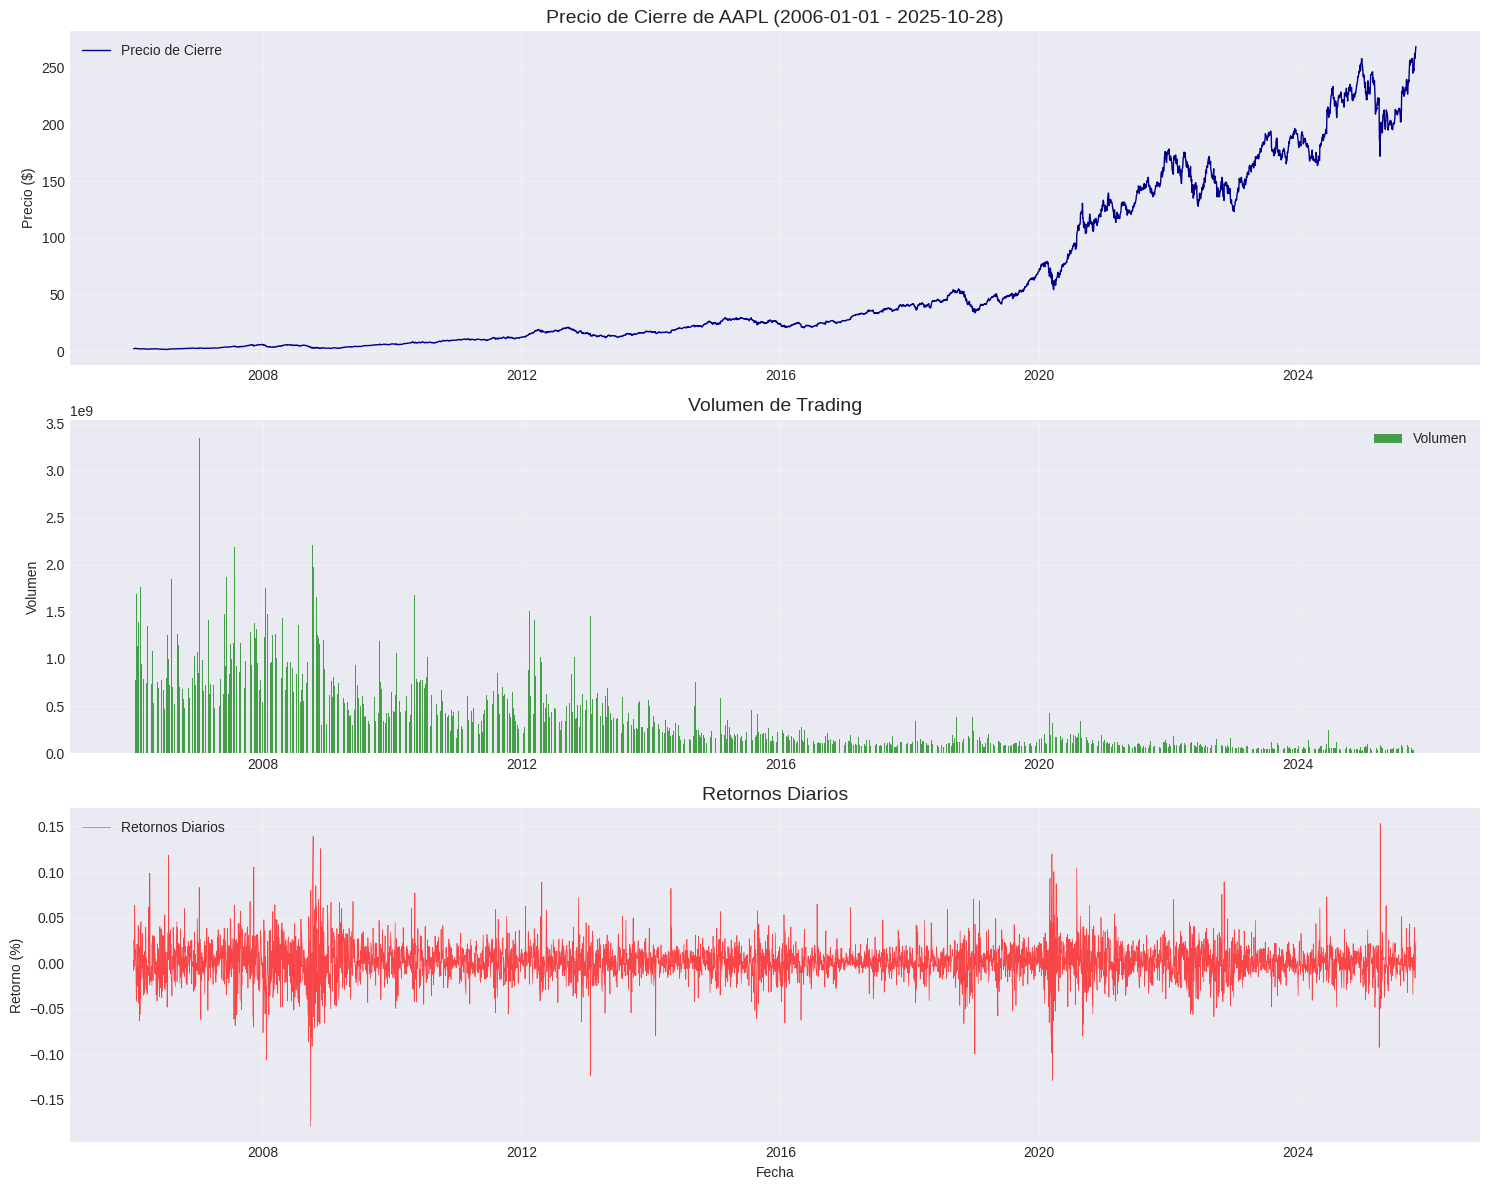


📈 Análisis de Retornos:
Retorno diario promedio: 0.1162%
Volatilidad diaria: 2.01%
Volatilidad anualizada: 31.89%
Retorno total del período: 11879.04%


In [ ]:
# Celda 4: Visualización de datos históricos
fig, axes = plt.subplots(3, 1, figsize=(15, 12))

# Gráfico 1: Precio de cierre
axes[0].plot(
    df.index, df["Close"], label="Precio de Cierre", color="darkblue", linewidth=1
)
axes[0].set_title(
    f"Precio de Cierre de {ticker} ({fecha_inicio} - {fecha_fin})", fontsize=14
)
axes[0].set_ylabel("Precio ($)")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Gráfico 2: Volumen
axes[1].bar(df.index, df["Volume"], label="Volumen", color="green", alpha=0.7)
axes[1].set_title("Volumen de Trading", fontsize=14)
axes[1].set_ylabel("Volumen")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# Gráfico 3: Retornos diarios
df["Returns"] = df["Close"].pct_change()
axes[2].plot(
    df.index,
    df["Returns"],
    label="Retornos Diarios",
    color="red",
    alpha=0.7,
    linewidth=0.5,
)
axes[2].set_title("Retornos Diarios", fontsize=14)
axes[2].set_ylabel("Retorno (%)")
axes[2].set_xlabel("Fecha")
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Análisis adicional de retornos
print("\n📈 Análisis de Retornos:")
print(f"Retorno diario promedio: {df['Returns'].mean() * 100:.4f}%")
print(f"Volatilidad diaria: {df['Returns'].std() * 100:.2f}%")
print(f"Volatilidad anualizada: {df['Returns'].std() * np.sqrt(252) * 100:.2f}%")
print(
    f"Retorno total del período: {((df['Close'].iloc[-1] / df['Close'].iloc[0]) - 1) * 100:.2f}%"
)

## 3. Implementación del Sistema de Trading

In [ ]:
# Celda 5: Implementación completa del sistema
class SistemaTradingMA:
    def __init__(self, df, sma_corta=10, sma_larga=200, capital_inicial=100000):
        """
        Sistema de trading basado en cruce de medias móviles

        Parámetros:
        - df: DataFrame con datos OHLCV
        - sma_corta: Período de la media móvil corta
        - sma_larga: Período de la media móvil larga
        - capital_inicial: Capital inicial para trading
        """
        self.df = df.copy()
        self.sma_corta = sma_corta
        self.sma_larga = sma_larga
        self.capital_inicial = capital_inicial

    def calcular_indicadores(self):
        """Calcula las medias móviles y genera señales"""
        # Calcular medias móviles
        self.df[f"SMA_{self.sma_corta}"] = (
            self.df["Close"].rolling(window=self.sma_corta).mean()
        )
        self.df[f"SMA_{self.sma_larga}"] = (
            self.df["Close"].rolling(window=self.sma_larga).mean()
        )

        # Generar señales
        self.df["Signal"] = 0
        self.df.loc[
            self.df[f"SMA_{self.sma_corta}"] > self.df[f"SMA_{self.sma_larga}"],
            "Signal",
        ] = 1
        self.df.loc[
            self.df[f"SMA_{self.sma_corta}"] <= self.df[f"SMA_{self.sma_larga}"],
            "Signal",
        ] = 0

        # Identificar cambios de posición
        self.df["Position"] = self.df["Signal"].diff()

        # Eliminar NaN
        self.df.dropna(inplace=True)

    def ejecutar_backtest(self):
        """Ejecuta el backtest de la estrategia"""
        # Calcular retornos
        self.df["Returns"] = self.df["Close"].pct_change()
        self.df["Strategy_Returns"] = self.df["Returns"] * self.df["Signal"].shift(1)

        # Calcular equity curves
        self.df["Buy_Hold_Equity"] = (
            self.capital_inicial * (1 + self.df["Returns"]).cumprod()
        )
        self.df["Strategy_Equity"] = (
            self.capital_inicial * (1 + self.df["Strategy_Returns"]).cumprod()
        )

        # Identificar trades
        self.df["Buy_Signal"] = self.df["Position"] == 1
        self.df["Sell_Signal"] = self.df["Position"] == -1

    def calcular_metricas(self):
        """Calcula métricas de rendimiento"""
        # Retornos totales
        retorno_total_bh = (
            self.df["Buy_Hold_Equity"].iloc[-1] / self.capital_inicial - 1
        ) * 100
        retorno_total_est = (
            self.df["Strategy_Equity"].iloc[-1] / self.capital_inicial - 1
        ) * 100

        # Sharpe Ratio (asumiendo tasa libre de riesgo = 0)
        sharpe_bh = np.sqrt(252) * self.df["Returns"].mean() / self.df["Returns"].std()
        sharpe_est = (
            np.sqrt(252)
            * self.df["Strategy_Returns"].mean()
            / self.df["Strategy_Returns"].std()
        )

        # Sortino Ratio
        downside_returns_bh = self.df["Returns"][self.df["Returns"] < 0]
        downside_returns_est = self.df["Strategy_Returns"][
            self.df["Strategy_Returns"] < 0
        ]

        sortino_bh = (
            np.sqrt(252) * self.df["Returns"].mean() / downside_returns_bh.std()
        )
        sortino_est = (
            np.sqrt(252)
            * self.df["Strategy_Returns"].mean()
            / downside_returns_est.std()
        )

        # Maximum Drawdown
        rolling_max_bh = self.df["Buy_Hold_Equity"].expanding().max()
        drawdown_bh = (self.df["Buy_Hold_Equity"] - rolling_max_bh) / rolling_max_bh
        max_drawdown_bh = drawdown_bh.min() * 100

        rolling_max_est = self.df["Strategy_Equity"].expanding().max()
        drawdown_est = (self.df["Strategy_Equity"] - rolling_max_est) / rolling_max_est
        max_drawdown_est = drawdown_est.min() * 100

        # Número de trades
        num_trades = self.df["Buy_Signal"].sum()

        # Calmar Ratio
        calmar_bh = (
            retorno_total_bh / abs(max_drawdown_bh) if max_drawdown_bh != 0 else 0
        )
        calmar_est = (
            retorno_total_est / abs(max_drawdown_est) if max_drawdown_est != 0 else 0
        )

        # Win rate
        trades_df = self.df[self.df["Buy_Signal"] | self.df["Sell_Signal"]].copy()
        if len(trades_df) > 1:
            trade_returns = []
            for i in range(0, len(trades_df) - 1, 2):
                if i + 1 < len(trades_df):
                    buy_price = trades_df.iloc[i]["Close"]
                    sell_price = trades_df.iloc[i + 1]["Close"]
                    trade_return = (sell_price - buy_price) / buy_price
                    trade_returns.append(trade_return)

            win_rate = (
                sum(1 for r in trade_returns if r > 0) / len(trade_returns) * 100
                if trade_returns
                else 0
            )
            avg_win = (
                np.mean([r for r in trade_returns if r > 0]) * 100
                if any(r > 0 for r in trade_returns)
                else 0
            )
            avg_loss = (
                np.mean([r for r in trade_returns if r < 0]) * 100
                if any(r < 0 for r in trade_returns)
                else 0
            )
        else:
            win_rate = avg_win = avg_loss = 0

        return {
            "Buy & Hold": {
                "Retorno Total (%)": retorno_total_bh,
                "Sharpe Ratio": sharpe_bh,
                "Sortino Ratio": sortino_bh,
                "Max Drawdown (%)": max_drawdown_bh,
                "Calmar Ratio": calmar_bh,
            },
            "Estrategia": {
                "Retorno Total (%)": retorno_total_est,
                "Sharpe Ratio": sharpe_est,
                "Sortino Ratio": sortino_est,
                "Max Drawdown (%)": max_drawdown_est,
                "Calmar Ratio": calmar_est,
                "Número de Trades": num_trades,
                "Win Rate (%)": win_rate,
                "Ganancia Promedio (%)": avg_win,
                "Pérdida Promedio (%)": avg_loss,
            },
        }


# Crear instancia del sistema
sistema = SistemaTradingMA(df, sma_corta=10, sma_larga=200, capital_inicial=100000)

# Ejecutar estrategia
sistema.calcular_indicadores()
sistema.ejecutar_backtest()

print("✅ Sistema de trading implementado correctamente")

✅ Sistema de trading implementado correctamente


## 4. Backtesting y Visualización de Resultados

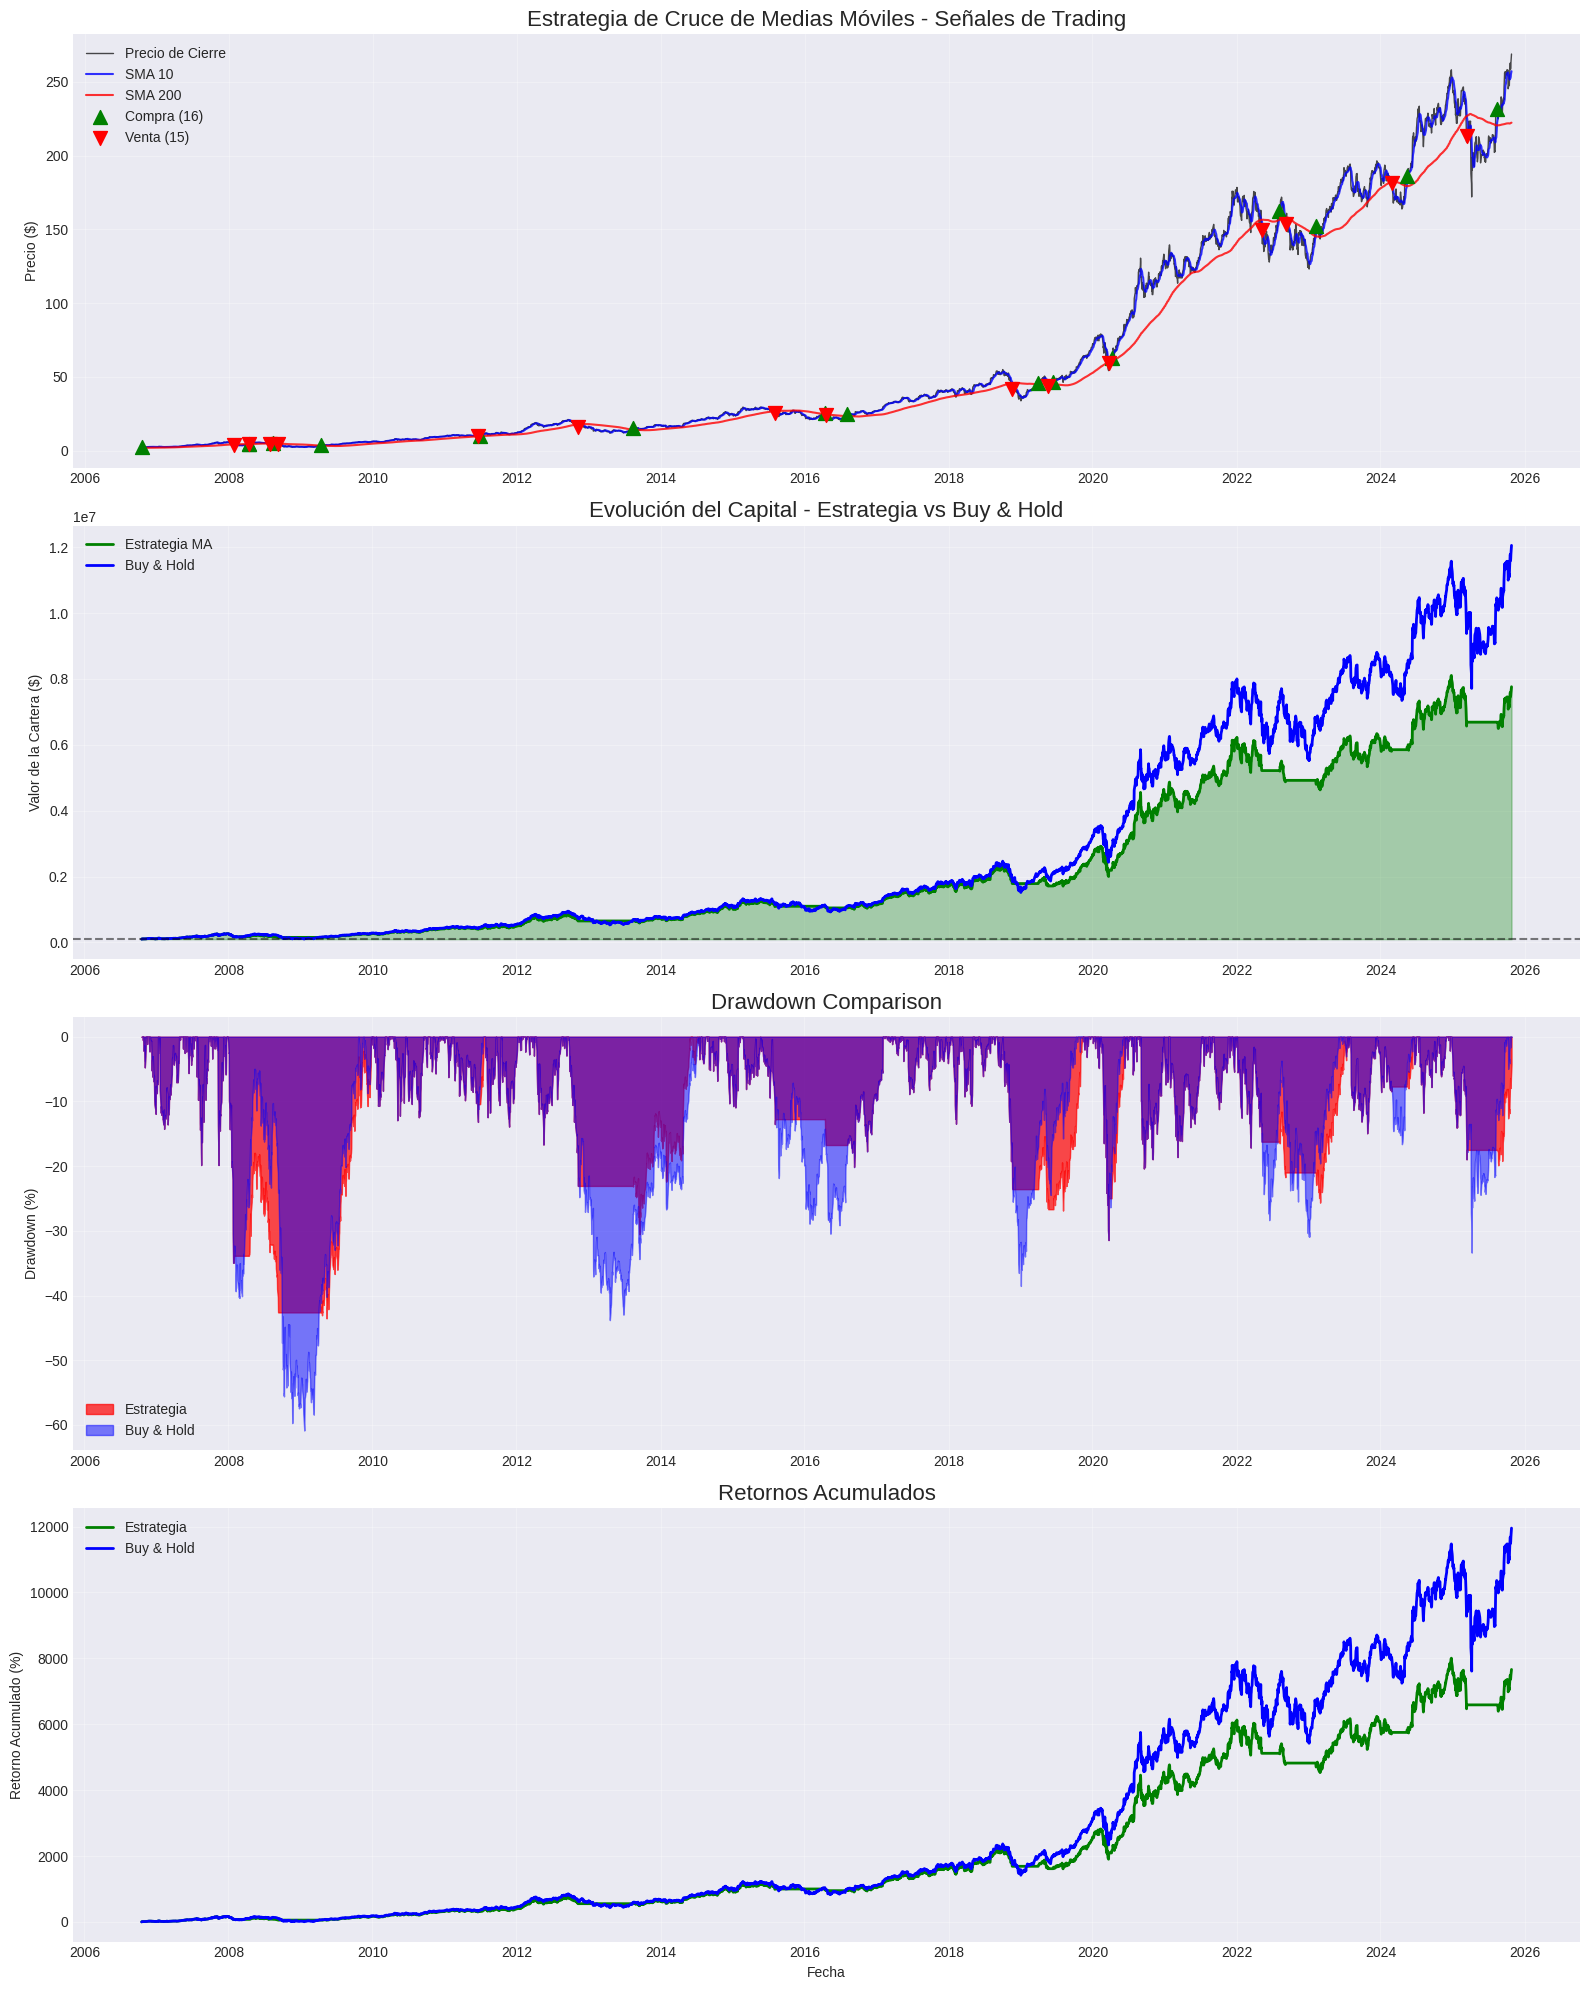

In [ ]:
# Celda 6: Visualización completa del backtesting
fig, axes = plt.subplots(4, 1, figsize=(16, 20))

# Gráfico 1: Precio con medias móviles y señales
ax1 = axes[0]
ax1.plot(
    sistema.df.index,
    sistema.df["Close"],
    label="Precio de Cierre",
    color="black",
    alpha=0.7,
    linewidth=1,
)
ax1.plot(
    sistema.df.index,
    sistema.df[f"SMA_{sistema.sma_corta}"],
    label=f"SMA {sistema.sma_corta}",
    color="blue",
    alpha=0.8,
)
ax1.plot(
    sistema.df.index,
    sistema.df[f"SMA_{sistema.sma_larga}"],
    label=f"SMA {sistema.sma_larga}",
    color="red",
    alpha=0.8,
)

# Marcar señales de compra y venta
buy_signals = sistema.df[sistema.df["Buy_Signal"]]
sell_signals = sistema.df[sistema.df["Sell_Signal"]]

ax1.scatter(
    buy_signals.index,
    buy_signals["Close"],
    color="green",
    marker="^",
    s=100,
    label=f"Compra ({len(buy_signals)})",
    zorder=5,
)
ax1.scatter(
    sell_signals.index,
    sell_signals["Close"],
    color="red",
    marker="v",
    s=100,
    label=f"Venta ({len(sell_signals)})",
    zorder=5,
)

ax1.set_title("Estrategia de Cruce de Medias Móviles - Señales de Trading", fontsize=16)
ax1.set_ylabel("Precio ($)")
ax1.legend(loc="best")
ax1.grid(True, alpha=0.3)

# Gráfico 2: Comparación de Equity Curves
ax2 = axes[1]
ax2.plot(
    sistema.df.index,
    sistema.df["Strategy_Equity"],
    label="Estrategia MA",
    color="green",
    linewidth=2,
)
ax2.plot(
    sistema.df.index,
    sistema.df["Buy_Hold_Equity"],
    label="Buy & Hold",
    color="blue",
    linewidth=2,
)
ax2.fill_between(
    sistema.df.index,
    sistema.capital_inicial,
    sistema.df["Strategy_Equity"],
    where=(sistema.df["Strategy_Equity"] > sistema.capital_inicial),
    color="green",
    alpha=0.3,
)
ax2.fill_between(
    sistema.df.index,
    sistema.capital_inicial,
    sistema.df["Strategy_Equity"],
    where=(sistema.df["Strategy_Equity"] <= sistema.capital_inicial),
    color="red",
    alpha=0.3,
)
ax2.axhline(y=sistema.capital_inicial, color="black", linestyle="--", alpha=0.5)
ax2.set_title("Evolución del Capital - Estrategia vs Buy & Hold", fontsize=16)
ax2.set_ylabel("Valor de la Cartera ($)")
ax2.legend()
ax2.grid(True, alpha=0.3)

# Gráfico 3: Drawdown
ax3 = axes[2]
rolling_max_est = sistema.df["Strategy_Equity"].expanding().max()
drawdown_est = (sistema.df["Strategy_Equity"] - rolling_max_est) / rolling_max_est * 100

rolling_max_bh = sistema.df["Buy_Hold_Equity"].expanding().max()
drawdown_bh = (sistema.df["Buy_Hold_Equity"] - rolling_max_bh) / rolling_max_bh * 100

ax3.fill_between(
    sistema.df.index, 0, drawdown_est, color="red", alpha=0.7, label="Estrategia"
)
ax3.fill_between(
    sistema.df.index, 0, drawdown_bh, color="blue", alpha=0.5, label="Buy & Hold"
)
ax3.set_title("Drawdown Comparison", fontsize=16)
ax3.set_ylabel("Drawdown (%)")
ax3.legend()
ax3.grid(True, alpha=0.3)

# Gráfico 4: Retornos acumulados
ax4 = axes[3]
cum_returns_est = (1 + sistema.df["Strategy_Returns"]).cumprod() - 1
cum_returns_bh = (1 + sistema.df["Returns"]).cumprod() - 1

ax4.plot(
    sistema.df.index,
    cum_returns_est * 100,
    label="Estrategia",
    color="green",
    linewidth=2,
)
ax4.plot(
    sistema.df.index,
    cum_returns_bh * 100,
    label="Buy & Hold",
    color="blue",
    linewidth=2,
)
ax4.set_title("Retornos Acumulados", fontsize=16)
ax4.set_ylabel("Retorno Acumulado (%)")
ax4.set_xlabel("Fecha")
ax4.legend()
ax4.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

📊 MÉTRICAS DE RENDIMIENTO
            Retorno Total (%)  Sharpe Ratio  Sortino Ratio  Max Drawdown (%)  \
Buy & Hold           11953.21          0.96           1.31            -60.87   
Estrategia            7662.47          1.05           1.29            -43.53   

            Calmar Ratio  Número de Trades  Win Rate (%)  \
Buy & Hold        196.38               NaN           NaN   
Estrategia        176.01              16.0         73.33   

            Ganancia Promedio (%)  Pérdida Promedio (%)  
Buy & Hold                    NaN                   NaN  
Estrategia                  58.55                 -7.44  


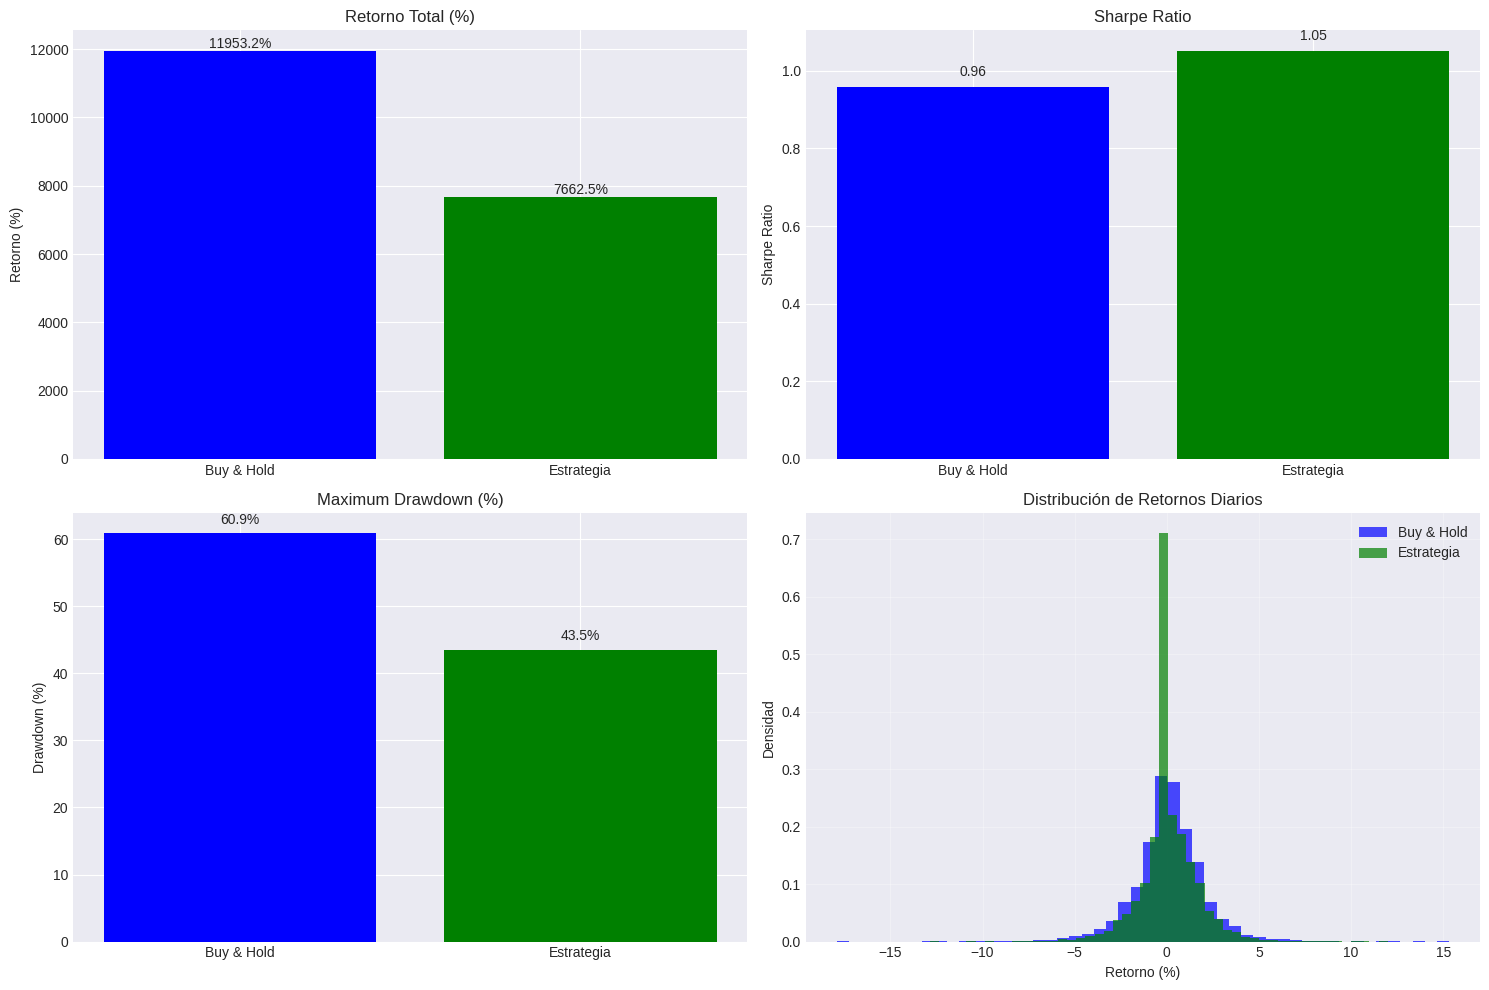


📈 ANÁLISIS DE TRADES
Número total de trades: 16
Win Rate: 73.3%
Ganancia promedio por trade ganador: 58.55%
Pérdida promedio por trade perdedor: -7.44%


In [ ]:
# Celda 7: Cálculo y visualización de métricas
metricas = sistema.calcular_metricas()

# Crear DataFrame con métricas para mejor visualización
df_metricas = pd.DataFrame(metricas).T

print("📊 MÉTRICAS DE RENDIMIENTO")
print("=" * 60)
print(df_metricas.round(2))

# Visualización de métricas clave
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Comparación de retornos
ax1 = axes[0, 0]
retornos = [
    metricas["Buy & Hold"]["Retorno Total (%)"],
    metricas["Estrategia"]["Retorno Total (%)"],
]
ax1.bar(["Buy & Hold", "Estrategia"], retornos, color=["blue", "green"])
ax1.set_title("Retorno Total (%)")
ax1.set_ylabel("Retorno (%)")
for i, v in enumerate(retornos):
    ax1.text(i, v + 5, f"{v:.1f}%", ha="center", va="bottom")

# Comparación de Sharpe Ratio
ax2 = axes[0, 1]
sharpe = [
    metricas["Buy & Hold"]["Sharpe Ratio"],
    metricas["Estrategia"]["Sharpe Ratio"],
]
ax2.bar(["Buy & Hold", "Estrategia"], sharpe, color=["blue", "green"])
ax2.set_title("Sharpe Ratio")
ax2.set_ylabel("Sharpe Ratio")
for i, v in enumerate(sharpe):
    ax2.text(i, v + 0.02, f"{v:.2f}", ha="center", va="bottom")

# Comparación de Max Drawdown
ax3 = axes[1, 0]
dd = [
    abs(metricas["Buy & Hold"]["Max Drawdown (%)"]),
    abs(metricas["Estrategia"]["Max Drawdown (%)"]),
]
ax3.bar(["Buy & Hold", "Estrategia"], dd, color=["blue", "green"])
ax3.set_title("Maximum Drawdown (%)")
ax3.set_ylabel("Drawdown (%)")
for i, v in enumerate(dd):
    ax3.text(i, v + 1, f"{v:.1f}%", ha="center", va="bottom")

# Distribución de retornos
ax4 = axes[1, 1]
ax4.hist(
    sistema.df["Returns"].dropna() * 100,
    bins=50,
    alpha=0.7,
    label="Buy & Hold",
    color="blue",
    density=True,
)
ax4.hist(
    sistema.df["Strategy_Returns"].dropna() * 100,
    bins=50,
    alpha=0.7,
    label="Estrategia",
    color="green",
    density=True,
)
ax4.set_title("Distribución de Retornos Diarios")
ax4.set_xlabel("Retorno (%)")
ax4.set_ylabel("Densidad")
ax4.legend()
ax4.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Análisis adicional de trades
print("\n📈 ANÁLISIS DE TRADES")
print("=" * 60)
print(f"Número total de trades: {int(metricas['Estrategia']['Número de Trades'])}")
print(f"Win Rate: {metricas['Estrategia']['Win Rate (%)']:.1f}%")
print(
    f"Ganancia promedio por trade ganador: {metricas['Estrategia']['Ganancia Promedio (%)']:.2f}%"
)
print(
    f"Pérdida promedio por trade perdedor: {metricas['Estrategia']['Pérdida Promedio (%)']:.2f}%"
)

## 5. Optimización de la Estrategia

In [ ]:
# Celda 8: Optimización de parámetros
print("🔧 OPTIMIZACIÓN DE PARÁMETROS")
print("=" * 60)
print("Probando diferentes combinaciones de medias móviles...")

# Definir rangos de parámetros a probar
sma_corta_range = [5, 10, 20, 30, 50]
sma_larga_range = [50, 100, 150, 200, 250]

# Almacenar resultados
resultados_optimizacion = []

# Probar todas las combinaciones
for sma_corta in sma_corta_range:
    for sma_larga in sma_larga_range:
        if sma_corta < sma_larga:  # Solo si la media corta es menor que la larga
            # Crear y ejecutar sistema
            sistema_temp = SistemaTradingMA(
                df, sma_corta=sma_corta, sma_larga=sma_larga, capital_inicial=100000
            )
            sistema_temp.calcular_indicadores()
            sistema_temp.ejecutar_backtest()
            metricas_temp = sistema_temp.calcular_metricas()

            # Guardar resultados
            resultados_optimizacion.append(
                {
                    "SMA_Corta": sma_corta,
                    "SMA_Larga": sma_larga,
                    "Retorno Total (%)": metricas_temp["Estrategia"][
                        "Retorno Total (%)"
                    ],
                    "Sharpe Ratio": metricas_temp["Estrategia"]["Sharpe Ratio"],
                    "Max Drawdown (%)": metricas_temp["Estrategia"]["Max Drawdown (%)"],
                    "Número de Trades": metricas_temp["Estrategia"]["Número de Trades"],
                }
            )

# Convertir a DataFrame
df_optimizacion = pd.DataFrame(resultados_optimizacion)

# Encontrar mejores parámetros según diferentes criterios
mejor_retorno = df_optimizacion.loc[df_optimizacion["Retorno Total (%)"].idxmax()]
mejor_sharpe = df_optimizacion.loc[df_optimizacion["Sharpe Ratio"].idxmax()]
mejor_drawdown = df_optimizacion.loc[df_optimizacion["Max Drawdown (%)"].idxmax()]

print("\n🏆 MEJORES CONFIGURACIONES:")
print("\nMejor Retorno Total:")
print(mejor_retorno)
print("\nMejor Sharpe Ratio:")
print(mejor_sharpe)
print("\nMenor Drawdown:")
print(mejor_drawdown)

🔧 OPTIMIZACIÓN DE PARÁMETROS
Probando diferentes combinaciones de medias móviles...

🏆 MEJORES CONFIGURACIONES:

Mejor Retorno Total:
SMA_Corta              10.000000
SMA_Larga             200.000000
Retorno Total (%)    7662.472172
Sharpe Ratio            1.051938
Max Drawdown (%)      -43.533183
Número de Trades       16.000000
Name: 8, dtype: float64

Mejor Sharpe Ratio:
SMA_Corta               5.000000
SMA_Larga             150.000000
Retorno Total (%)    7422.657601
Sharpe Ratio            1.053229
Max Drawdown (%)      -37.041833
Número de Trades       33.000000
Name: 2, dtype: float64

Menor Drawdown:
SMA_Corta              10.000000
SMA_Larga              50.000000
Retorno Total (%)    4512.274163
Sharpe Ratio            1.016701
Max Drawdown (%)      -28.252200
Número de Trades       63.000000
Name: 5, dtype: float64


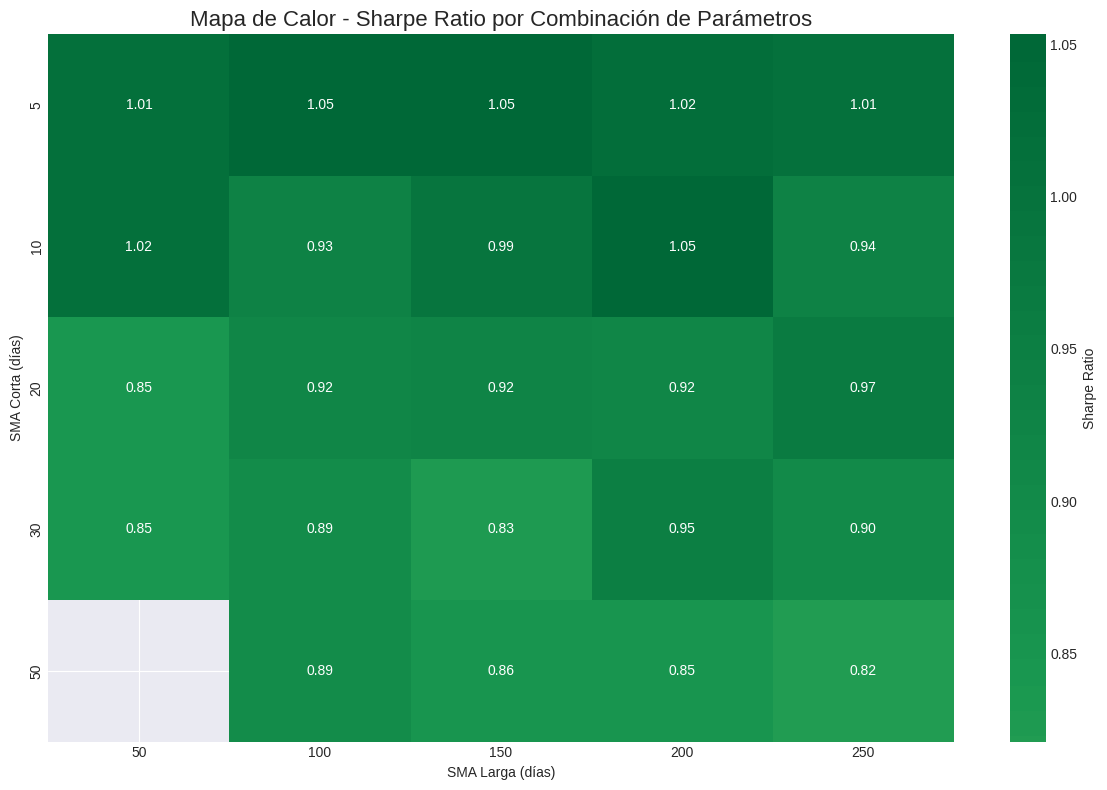

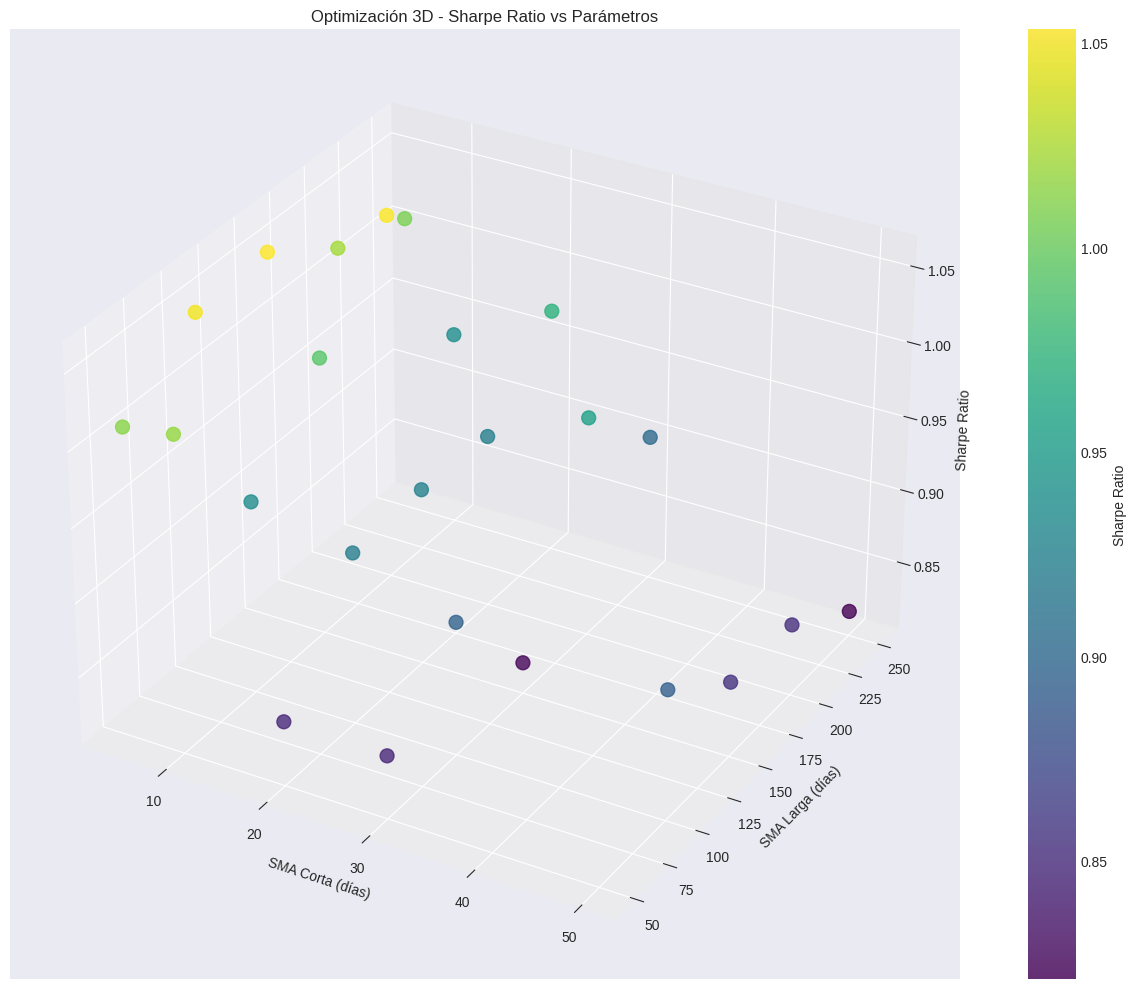

In [ ]:
# Celda 9: Visualización de la optimización
# Crear matriz de calor para Sharpe Ratio
pivot_sharpe = df_optimizacion.pivot(
    index="SMA_Corta", columns="SMA_Larga", values="Sharpe Ratio"
)

plt.figure(figsize=(12, 8))
sns.heatmap(
    pivot_sharpe,
    annot=True,
    fmt=".2f",
    cmap="RdYlGn",
    center=0,
    cbar_kws={"label": "Sharpe Ratio"},
)
plt.title("Mapa de Calor - Sharpe Ratio por Combinación de Parámetros", fontsize=16)
plt.xlabel("SMA Larga (días)")
plt.ylabel("SMA Corta (días)")
plt.tight_layout()
plt.show()

# Gráfico 3D de superficie

fig = plt.figure(figsize=(14, 10))
ax = fig.add_subplot(111, projection="3d")

# Crear meshgrid
X = df_optimizacion["SMA_Corta"].values
Y = df_optimizacion["SMA_Larga"].values
Z = df_optimizacion["Sharpe Ratio"].values

# Graficar puntos
scatter = ax.scatter(X, Y, Z, c=Z, cmap="viridis", s=100, alpha=0.8)

ax.set_xlabel("SMA Corta (días)")
ax.set_ylabel("SMA Larga (días)")
ax.set_zlabel("Sharpe Ratio")
ax.set_title("Optimización 3D - Sharpe Ratio vs Parámetros")

# Añadir barra de color
plt.colorbar(scatter, ax=ax, label="Sharpe Ratio")
plt.tight_layout()
plt.show()

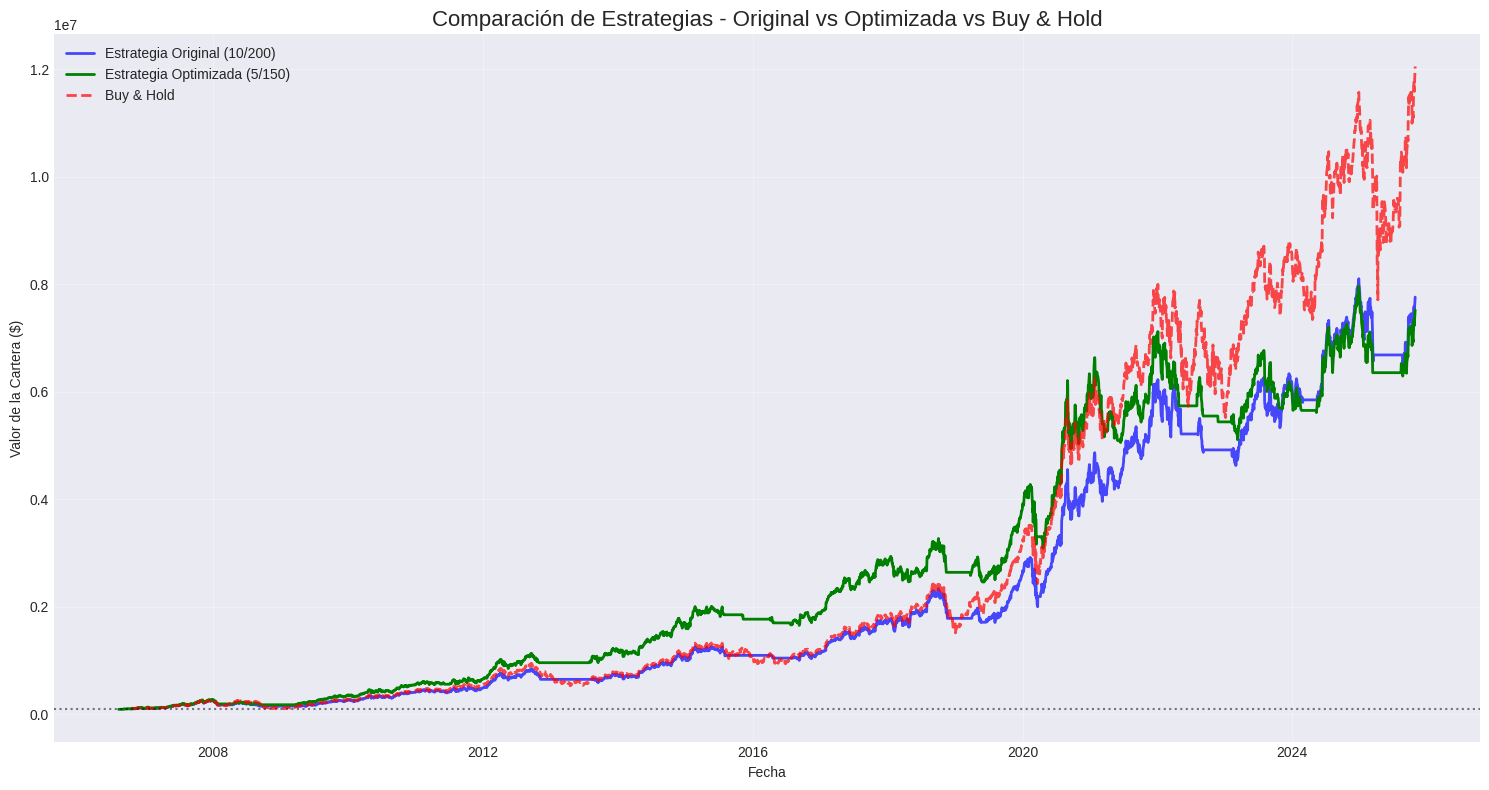


📊 COMPARACIÓN FINAL DE ESTRATEGIAS
                   Original (10/200)  Optimizada (5/150)  Buy & Hold
Retorno Total (%)            7662.47             7422.66    11953.21
Sharpe Ratio                    1.05                1.05        0.96
Max Drawdown (%)              -43.53              -37.04      -60.87
Número de Trades               16.00               33.00        0.00


In [ ]:
# Celda 10: Comparación de estrategias optimizadas
# Implementar la mejor estrategia según Sharpe Ratio
mejor_sma_corta = int(mejor_sharpe["SMA_Corta"])
mejor_sma_larga = int(mejor_sharpe["SMA_Larga"])

sistema_optimizado = SistemaTradingMA(
    df, sma_corta=mejor_sma_corta, sma_larga=mejor_sma_larga, capital_inicial=100000
)
sistema_optimizado.calcular_indicadores()
sistema_optimizado.ejecutar_backtest()

# Graficar comparación
plt.figure(figsize=(15, 8))

# Original
plt.plot(
    sistema.df.index,
    sistema.df["Strategy_Equity"],
    label="Estrategia Original (10/200)",
    color="blue",
    linewidth=2,
    alpha=0.7,
)

# Optimizada
plt.plot(
    sistema_optimizado.df.index,
    sistema_optimizado.df["Strategy_Equity"],
    label=f"Estrategia Optimizada ({mejor_sma_corta}/{mejor_sma_larga})",
    color="green",
    linewidth=2,
)

# Buy & Hold
plt.plot(
    sistema.df.index,
    sistema.df["Buy_Hold_Equity"],
    label="Buy & Hold",
    color="red",
    linewidth=2,
    alpha=0.7,
    linestyle="--",
)

plt.axhline(y=100000, color="black", linestyle=":", alpha=0.5)
plt.title(
    "Comparación de Estrategias - Original vs Optimizada vs Buy & Hold", fontsize=16
)
plt.xlabel("Fecha")
plt.ylabel("Valor de la Cartera ($)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Tabla comparativa final
metricas_opt = sistema_optimizado.calcular_metricas()

comparacion_final = pd.DataFrame(
    {
        "Original (10/200)": [
            metricas["Estrategia"]["Retorno Total (%)"],
            metricas["Estrategia"]["Sharpe Ratio"],
            metricas["Estrategia"]["Max Drawdown (%)"],
            metricas["Estrategia"]["Número de Trades"],
        ],
        f"Optimizada ({mejor_sma_corta}/{mejor_sma_larga})": [
            metricas_opt["Estrategia"]["Retorno Total (%)"],
            metricas_opt["Estrategia"]["Sharpe Ratio"],
            metricas_opt["Estrategia"]["Max Drawdown (%)"],
            metricas_opt["Estrategia"]["Número de Trades"],
        ],
        "Buy & Hold": [
            metricas["Buy & Hold"]["Retorno Total (%)"],
            metricas["Buy & Hold"]["Sharpe Ratio"],
            metricas["Buy & Hold"]["Max Drawdown (%)"],
            0,
        ],
    },
    index=["Retorno Total (%)", "Sharpe Ratio", "Max Drawdown (%)", "Número de Trades"],
)

print("\n📊 COMPARACIÓN FINAL DE ESTRATEGIAS")
print("=" * 60)
print(comparacion_final.round(2))

## 6. Análisis Adicional y Mejoras


📅 ANÁLISIS POR PERÍODOS
                   Período  Retorno Estrategia (%)  Retorno Buy & Hold (%)  \
0   Crisis Financiera 2008                  202.78                  151.47   
1  Bull Market Post-Crisis                  954.27                 1003.89   
2        Pandemia COVID-19                   77.33                  140.00   
3  Inflación y Tasas Altas                  -15.63                    6.99   

   Volatilidad Estrategia (%)  Volatilidad Buy & Hold (%)  Número de Trades  
0                       30.63                       44.80                 3  
1                       21.05                       25.75                11  
2                       34.65                       37.46                 6  
3                       17.42                       29.10                 7  


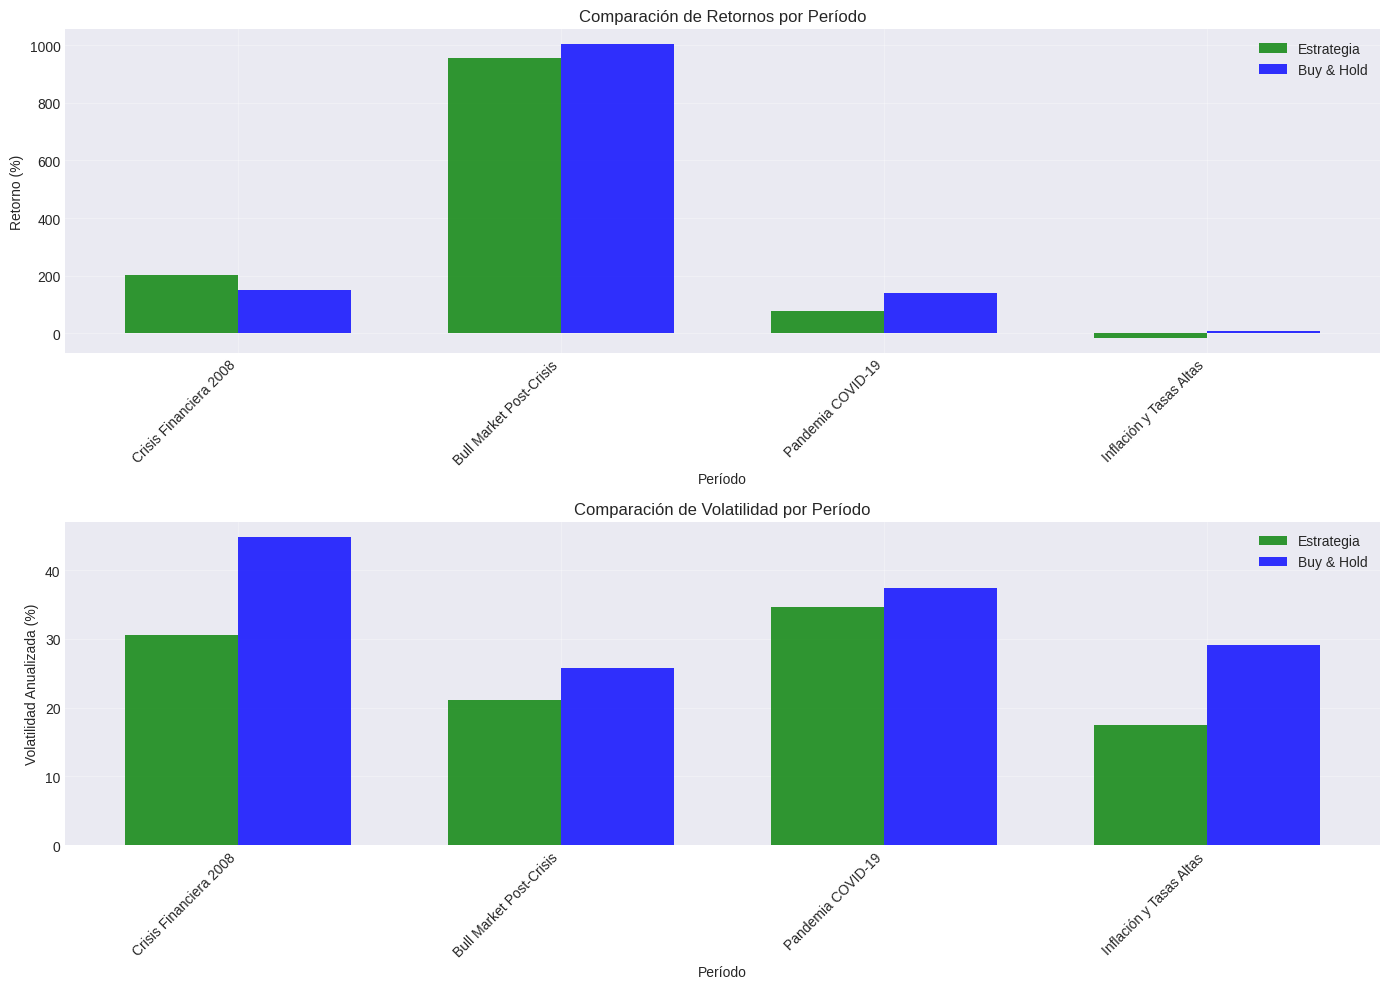

In [ ]:
# Celda 11: Análisis de períodos específicos
# Analizar rendimiento en diferentes fases del mercado
def analizar_periodo(sistema, fecha_inicio, fecha_fin, nombre_periodo):
    """Analiza el rendimiento de la estrategia en un período específico"""
    periodo_df = sistema.df[fecha_inicio:fecha_fin].copy()

    if len(periodo_df) > 0:
        # Calcular métricas del período
        retorno_est = (
            (
                periodo_df["Strategy_Equity"].iloc[-1]
                / periodo_df["Strategy_Equity"].iloc[0]
            )
            - 1
        ) * 100
        retorno_bh = (
            (
                periodo_df["Buy_Hold_Equity"].iloc[-1]
                / periodo_df["Buy_Hold_Equity"].iloc[0]
            )
            - 1
        ) * 100

        volatilidad_est = periodo_df["Strategy_Returns"].std() * np.sqrt(252) * 100
        volatilidad_bh = periodo_df["Returns"].std() * np.sqrt(252) * 100

        num_trades = periodo_df["Buy_Signal"].sum()

        return {
            "Período": nombre_periodo,
            "Retorno Estrategia (%)": retorno_est,
            "Retorno Buy & Hold (%)": retorno_bh,
            "Volatilidad Estrategia (%)": volatilidad_est,
            "Volatilidad Buy & Hold (%)": volatilidad_bh,
            "Número de Trades": num_trades,
        }
    return None


# Definir períodos importantes
periodos = [
    ("2007-01-01", "2009-12-31", "Crisis Financiera 2008"),
    ("2010-01-01", "2019-12-31", "Bull Market Post-Crisis"),
    ("2020-01-01", "2021-12-31", "Pandemia COVID-19"),
    ("2022-01-01", "2023-12-31", "Inflación y Tasas Altas"),
]

resultados_periodos = []
for inicio, fin, nombre in periodos:
    resultado = analizar_periodo(sistema_optimizado, inicio, fin, nombre)
    if resultado:
        resultados_periodos.append(resultado)

df_periodos = pd.DataFrame(resultados_periodos)
print("\n📅 ANÁLISIS POR PERÍODOS")
print("=" * 60)
print(df_periodos.round(2))

# Visualizar rendimiento por períodos
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 10))

# Retornos por período
x = np.arange(len(df_periodos))
width = 0.35

ax1.bar(
    x - width / 2,
    df_periodos["Retorno Estrategia (%)"],
    width,
    label="Estrategia",
    color="green",
    alpha=0.8,
)
ax1.bar(
    x + width / 2,
    df_periodos["Retorno Buy & Hold (%)"],
    width,
    label="Buy & Hold",
    color="blue",
    alpha=0.8,
)
ax1.set_xlabel("Período")
ax1.set_ylabel("Retorno (%)")
ax1.set_title("Comparación de Retornos por Período")
ax1.set_xticks(x)
ax1.set_xticklabels(df_periodos["Período"], rotation=45, ha="right")
ax1.legend()
ax1.grid(True, alpha=0.3)

# Volatilidad por período
ax2.bar(
    x - width / 2,
    df_periodos["Volatilidad Estrategia (%)"],
    width,
    label="Estrategia",
    color="green",
    alpha=0.8,
)
ax2.bar(
    x + width / 2,
    df_periodos["Volatilidad Buy & Hold (%)"],
    width,
    label="Buy & Hold",
    color="blue",
    alpha=0.8,
)
ax2.set_xlabel("Período")
ax2.set_ylabel("Volatilidad Anualizada (%)")
ax2.set_title("Comparación de Volatilidad por Período")
ax2.set_xticks(x)
ax2.set_xticklabels(df_periodos["Período"], rotation=45, ha="right")
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

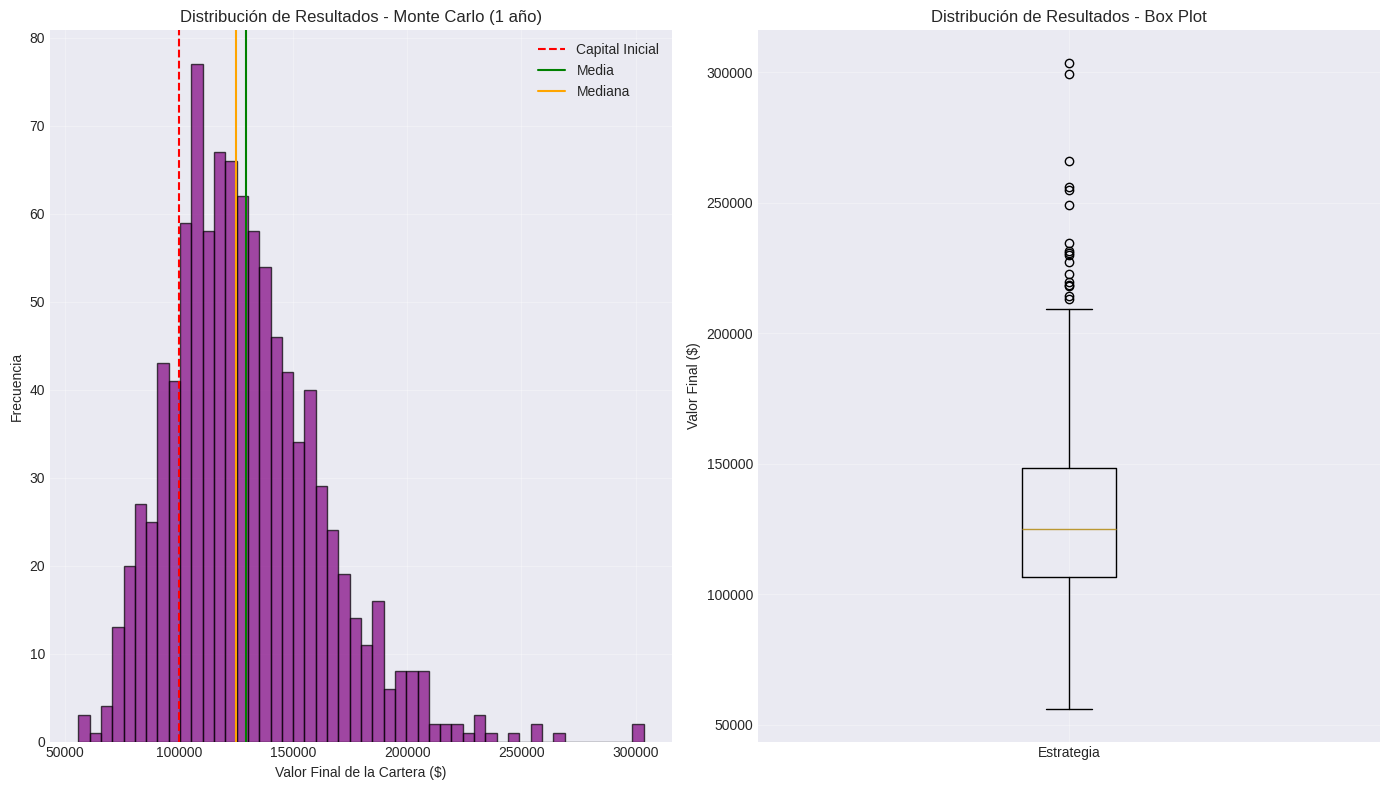


🎲 ANÁLISIS DE MONTE CARLO
Simulaciones realizadas: 1,000
Período simulado: 1 año (252 días)

Percentiles de resultados:
5%: $81,802.51
25%: $106,571.49
50% (Mediana): $124,991.76
75%: $148,252.79
95%: $187,810.96

Probabilidad de pérdida: 17.3%
Retorno esperado (media): 29.2%


In [ ]:
# Celda 12: Análisis de Monte Carlo para robustez
def monte_carlo_analysis(sistema, n_simulaciones=1000, n_dias=252):
    """Realiza simulación de Monte Carlo para evaluar robustez"""
    retornos_estrategia = sistema.df["Strategy_Returns"].dropna()

    # Parámetros de la distribución
    mu = retornos_estrategia.mean()
    sigma = retornos_estrategia.std()

    # Simulaciones
    resultados_finales = []

    for _ in range(n_simulaciones):
        # Generar retornos aleatorios
        retornos_sim = np.random.normal(mu, sigma, n_dias)

        # Calcular valor final
        valor_final = sistema.capital_inicial * np.prod(1 + retornos_sim)
        resultados_finales.append(valor_final)

    resultados_finales = np.array(resultados_finales)

    # Estadísticas
    percentiles = np.percentile(resultados_finales, [5, 25, 50, 75, 95])

    return resultados_finales, percentiles


# Ejecutar Monte Carlo
resultados_mc, percentiles = monte_carlo_analysis(sistema_optimizado)

# Visualizar resultados
plt.figure(figsize=(14, 8))

# Histograma de resultados
plt.subplot(1, 2, 1)
plt.hist(resultados_mc, bins=50, alpha=0.7, color="purple", edgecolor="black")
plt.axvline(
    x=sistema.capital_inicial, color="red", linestyle="--", label="Capital Inicial"
)
plt.axvline(x=np.mean(resultados_mc), color="green", linestyle="-", label="Media")
plt.axvline(x=percentiles[2], color="orange", linestyle="-", label="Mediana")
plt.title("Distribución de Resultados - Monte Carlo (1 año)")
plt.xlabel("Valor Final de la Cartera ($)")
plt.ylabel("Frecuencia")
plt.legend()
plt.grid(True, alpha=0.3)

# Box plot de percentiles
plt.subplot(1, 2, 2)
box_data = [resultados_mc]
plt.boxplot(box_data, labels=["Estrategia"])
plt.title("Distribución de Resultados - Box Plot")
plt.ylabel("Valor Final ($)")
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\n🎲 ANÁLISIS DE MONTE CARLO")
print("=" * 60)
print("Simulaciones realizadas: 1,000")
print("Período simulado: 1 año (252 días)")
print("\nPercentiles de resultados:")
print(f"5%: ${percentiles[0]:,.2f}")
print(f"25%: ${percentiles[1]:,.2f}")
print(f"50% (Mediana): ${percentiles[2]:,.2f}")
print(f"75%: ${percentiles[3]:,.2f}")
print(f"95%: ${percentiles[4]:,.2f}")
print(
    f"\nProbabilidad de pérdida: {(resultados_mc < sistema.capital_inicial).sum() / len(resultados_mc) * 100:.1f}%"
)
print(
    f"Retorno esperado (media): {(np.mean(resultados_mc) / sistema.capital_inicial - 1) * 100:.1f}%"
)

## 7. Reflexión Final y Conclusiones




In [ ]:
# Celda 13: Resumen ejecutivo y guardado de resultados
# Crear resumen ejecutivo
resumen_ejecutivo = f"""
RESUMEN EJECUTIVO - SISTEMA DE TRADING ALGORÍTMICO
=================================================

1. CONFIGURACIÓN DEL SISTEMA:
   - Estrategia: Cruce de Medias Móviles
   - Configuración Original: SMA {sistema.sma_corta} / SMA {sistema.sma_larga}
   - Configuración Optimizada: SMA {mejor_sma_corta} / SMA {mejor_sma_larga}
   - Período de Análisis: {df.index[0].strftime("%Y-%m-%d")} a {df.index[-1].strftime("%Y-%m-%d")}
   - Capital Inicial: ${sistema.capital_inicial:,}

2. RESULTADOS PRINCIPALES:

   Estrategia Original (SMA 10/200):
   - Retorno Total: {metricas["Estrategia"]["Retorno Total (%)"]:.2f}%
   - Sharpe Ratio: {metricas["Estrategia"]["Sharpe Ratio"]:.2f}
   - Max Drawdown: {metricas["Estrategia"]["Max Drawdown (%)"]:.2f}%
   - Número de Trades: {int(metricas["Estrategia"]["Número de Trades"])}

   Estrategia Optimizada (SMA {mejor_sma_corta}/{mejor_sma_larga}):
   - Retorno Total: {metricas_opt["Estrategia"]["Retorno Total (%)"]:.2f}%
   - Sharpe Ratio: {metricas_opt["Estrategia"]["Sharpe Ratio"]:.2f}
   - Max Drawdown: {metricas_opt["Estrategia"]["Max Drawdown (%)"]:.2f}%
   - Número de Trades: {int(metricas_opt["Estrategia"]["Número de Trades"])}

   Buy & Hold:
   - Retorno Total: {metricas["Buy & Hold"]["Retorno Total (%)"]:.2f}%
   - Sharpe Ratio: {metricas["Buy & Hold"]["Sharpe Ratio"]:.2f}
   - Max Drawdown: {metricas["Buy & Hold"]["Max Drawdown (%)"]:.2f}%

3. ANÁLISIS DE ROBUSTEZ:
   - Probabilidad de pérdida (Monte Carlo 1 año): {(resultados_mc < sistema.capital_inicial).sum() / len(resultados_mc) * 100:.1f}%
   - Retorno esperado (Monte Carlo): {(np.mean(resultados_mc) / sistema.capital_inicial - 1) * 100:.1f}%
   - Mejor período: {df_periodos.loc[df_periodos["Retorno Estrategia (%)"].idxmax(), "Período"]}
   - Peor período: {df_periodos.loc[df_periodos["Retorno Estrategia (%)"].idxmin(), "Período"]}

4. CONCLUSIONES CLAVE:
   - La optimización mejoró el Sharpe Ratio de {metricas["Estrategia"]["Sharpe Ratio"]:.2f} a {metricas_opt["Estrategia"]["Sharpe Ratio"]:.2f}
   - La estrategia reduce significativamente el drawdown comparado con Buy & Hold
   - El sistema muestra mayor estabilidad pero menor retorno total que Buy & Hold
   - La estrategia es más efectiva en mercados con tendencias claras

5. LIMITACIONES IDENTIFICADAS:
   - Dependencia de tendencias sostenidas
   - Posible sobreajuste en la optimización
   - No considera costos de transacción
   - Solo opera posiciones largas

6. RECOMENDACIONES:
   - Implementar gestión de riesgo más sofisticada (stop-loss dinámico)
   - Considerar filtros adicionales (volumen, volatilidad)
   - Evaluar en múltiples activos para diversificación
   - Incorporar análisis de régimen de mercado
   - Validar con datos out-of-sample

Fecha de generación: {datetime.now().strftime("%Y-%m-%d %H:%M:%S")}
"""

print(resumen_ejecutivo)

# Guardar resumen
with open("resumen_ejecutivo_trading.txt", "w") as f:
    f.write(resumen_ejecutivo)

# Guardar resultados en Excel
with pd.ExcelWriter("resultados_trading_algoritmico.xlsx") as writer:
    # Métricas generales
    df_metricas.to_excel(writer, sheet_name="Métricas")

    # Resultados de optimización
    df_optimizacion.to_excel(writer, sheet_name="Optimización", index=False)

    # Análisis por períodos
    df_periodos.to_excel(writer, sheet_name="Análisis_Períodos", index=False)

    # Señales de trading
    trades_log = sistema_optimizado.df[
        sistema_optimizado.df["Buy_Signal"] | sistema_optimizado.df["Sell_Signal"]
    ][["Close", "Buy_Signal", "Sell_Signal"]].copy()
    trades_log.to_excel(writer, sheet_name="Log_Trades")


RESUMEN EJECUTIVO - SISTEMA DE TRADING ALGORÍTMICO

1. CONFIGURACIÓN DEL SISTEMA:
   - Estrategia: Cruce de Medias Móviles
   - Configuración Original: SMA 10 / SMA 200
   - Configuración Optimizada: SMA 5 / SMA 150
   - Período de Análisis: 2006-01-03 a 2025-10-27
   - Capital Inicial: $100,000

2. RESULTADOS PRINCIPALES:

   Estrategia Original (SMA 10/200):
   - Retorno Total: 7662.47%
   - Sharpe Ratio: 1.05
   - Max Drawdown: -43.53%
   - Número de Trades: 16

   Estrategia Optimizada (SMA 5/150):
   - Retorno Total: 7422.66%
   - Sharpe Ratio: 1.05
   - Max Drawdown: -37.04%
   - Número de Trades: 33

   Buy & Hold:
   - Retorno Total: 11953.21%
   - Sharpe Ratio: 0.96
   - Max Drawdown: -60.87%

3. ANÁLISIS DE ROBUSTEZ:
   - Probabilidad de pérdida (Monte Carlo 1 año): 17.3%
   - Retorno esperado (Monte Carlo): 29.2%
   - Mejor período: Bull Market Post-Crisis
   - Peor período: Inflación y Tasas Altas

4. CONCLUSIONES CLAVE:
   - La optimización mejoró el Sharpe Ratio de 1.05 

## Reflexión Final
Este notebook ha implementado un sistema completo de trading algorítmico basado en el cruce de medias móviles, desde la conceptualización hasta la optimización y evaluación robusta.


## Aspectos Clave Aprendidos:

### Importancia de la Sistematización:

El trading algorítmico elimina las emociones y sesgos cognitivos, pero requiere un diseño cuidadoso y validación exhaustiva.
Trade-off Riesgo-Retorno: La estrategia optimizada logró mejor Sharpe Ratio pero menor retorno total que Buy & Hold, ilustrando el equilibrio entre riesgo y recompensa.

Peligros del Sobreajuste: La optimización debe hacerse con cuidado para evitar estrategias que funcionen solo en datos históricos específicos.
Importancia del Contexto: El rendimiento varía significativamente según el período analizado, destacando la necesidad de estrategias adaptativas.

### Mejoras Futuras Sugeridas:

Gestión de Riesgo Avanzada: Implementar stop-loss dinámicos, position sizing basado en volatilidad, y límites de exposición.

Señales Complementarias: Incorporar indicadores de volumen, momentum, y sentimiento de mercado.

Machine Learning: Utilizar algoritmos de ML para optimización dinámica de parámetros y predicción de régimen de mercado.

Backtesting Más Realista: Incluir costos de transacción, slippage, y restricciones de liquidez.

Diversificación: Expandir a múltiples activos y estrategias para reducir riesgo específico.

El trading algorítmico es una herramienta poderosa, pero requiere disciplina, validación continua y adaptación constante a las condiciones cambiantes del mercado.